# Better BEBM MLP Training Diagnostics

This notebook analyzes the stronger BEBM MLP run:

`BEBM_MLP_MNIST_h500_DMALA100_lr1e-2_100k.h5`

The model is a one-hidden-layer MLP energy:

`visible -> Linear W1 -> SiLU -> Linear W2 -> scalar energy`, plus the fixed visible field baseline.

Compute cells and plotting cells are kept separate so visualizations can be rerun without recomputing expensive diagnostics.


In [1]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from rbms.dataset import load_dataset
from rbms.io import load_model, load_params
from rbms.plot import plot_mult_PCA
from rbms.utils import get_saved_updates

plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.family"] = "STIXGeneral"
plt.rcParams.update({"font.size": 13})

%load_ext autoreload
%autoreload 2


/Users/aidan/Documents/Research_Internship/Code/rbms/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
dtype = torch.float32

filename = "pcd_trains/BEBM_MLP_MNIST_h500_DMALA100_lr1e-2_100k.h5"
train_dataset_name = "data/MNIST_train.h5"
test_dataset_name = "data/MNIST_test.h5"

IMAGE_SHAPE = (28, 28)

print("device:", device)
print("filename:", filename)


device: cpu
filename: pcd_trains/BEBM_MLP_MNIST_h500_DMALA100_lr1e-2_100k.h5


## Load Data and Checkpoints


In [3]:
train_dataset, test_dataset = load_dataset(
    dataset_name=train_dataset_name,
    test_dataset_name=test_dataset_name,
    device=device,
    dtype=dtype,
)

train_visible = train_dataset.data.to(device=device, dtype=dtype)
num_visibles = train_dataset.get_num_visibles()
saved_updates = get_saved_updates(filename)

print("first update:", int(saved_updates[0]))
print("last update: ", int(saved_updates[-1]))
print("checkpoints: ", len(saved_updates))


Reading dataset from data/MNIST_train.h5...
    Done
Reading dataset from data/MNIST_test.h5...
    Done
first update: 1
last update:  100000
checkpoints:  1000


## Helpers


In [4]:
def selected_updates_decades(updates):
    updates = np.asarray(updates)
    max_update = int(updates[-1])
    targets = [int(updates[0])]

    decade = 100
    while decade <= max_update:
        for multiplier in range(1, 10):
            target = multiplier * decade
            if target <= max_update:
                targets.append(target)
        decade *= 10

    targets.append(max_update)
    targets = np.unique(targets)

    selected = []
    for target in targets:
        index = np.argmin(np.abs(updates - target))
        selected.append(updates[index])

    return np.unique(selected)


def selected_updates_linear(updates, num_points):
    indices = np.linspace(0, len(updates) - 1, num_points).round().astype(int)
    return np.asarray(updates)[np.unique(indices)]


def read_mlp_weights(filename, update):
    with h5py.File(filename, "r") as f:
        params_group = f[f"update_{int(update)}"]["params"]
        keys = list(params_group.keys())
        weight_keys = sorted(
            [key for key in keys if key.endswith(".weight")],
            key=lambda key: int(key.split(".")[1]),
        )
        weights = {key: torch.as_tensor(params_group[key][()], dtype=torch.float32) for key in weight_keys}
    return weights


def plot_binary_rows(samples_by_update, title, samples_per_checkpoint=8):
    num_rows = len(samples_by_update)
    fig, axes = plt.subplots(
        num_rows,
        samples_per_checkpoint,
        figsize=(samples_per_checkpoint, 1.35 * num_rows),
        squeeze=False,
    )

    for row, (update, visible) in enumerate(samples_by_update.items()):
        for col in range(samples_per_checkpoint):
            ax = axes[row, col]
            ax.imshow(visible[col].view(*IMAGE_SHAPE), cmap="gray_r", vmin=0, vmax=1)
            ax.axis("off")
        axes[row, 0].set_ylabel(f"update {update}", rotation=0, labelpad=40, va="center", fontsize=10)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


## MLP Weight Spectra Over Training

For the one-hidden-layer MLP:

- `W1 = net.0.weight`, shape `(hidden_dim, num_visibles)`.
- `W2 = net.2.weight`, shape `(1, hidden_dim)`.

For rectangular matrices we plot singular values. For `W1`, eigenvalues of `W1.T @ W1` are singular values squared, so we also plot squared singular values.


In [5]:
SPECTRA_TOP_K = 10
spectra_updates = selected_updates_decades(saved_updates)

spectra_history = {
    "updates": spectra_updates,
    "W1_singular": [],
    "W1_squared_singular": [],
    "W2_singular": [],
}

for update in tqdm(spectra_updates, desc="MLP spectra"):
    weights = read_mlp_weights(filename, update)
    W1 = weights["net.0.weight"]
    W2 = weights["net.2.weight"]

    s1 = torch.linalg.svdvals(W1).sort(descending=True).values[:SPECTRA_TOP_K]
    s2 = torch.linalg.svdvals(W2).sort(descending=True).values[:SPECTRA_TOP_K]

    spectra_history["W1_singular"].append(s1.cpu())
    spectra_history["W1_squared_singular"].append(s1.square().cpu())
    spectra_history["W2_singular"].append(s2.cpu())

spectra_history["W1_singular"] = torch.stack(spectra_history["W1_singular"]).numpy()
spectra_history["W1_squared_singular"] = torch.stack(spectra_history["W1_squared_singular"]).numpy()
spectra_history["W2_singular"] = torch.stack(spectra_history["W2_singular"]).numpy()


MLP spectra: 100%|██████████| 29/29 [00:00<00:00, 54.93it/s]


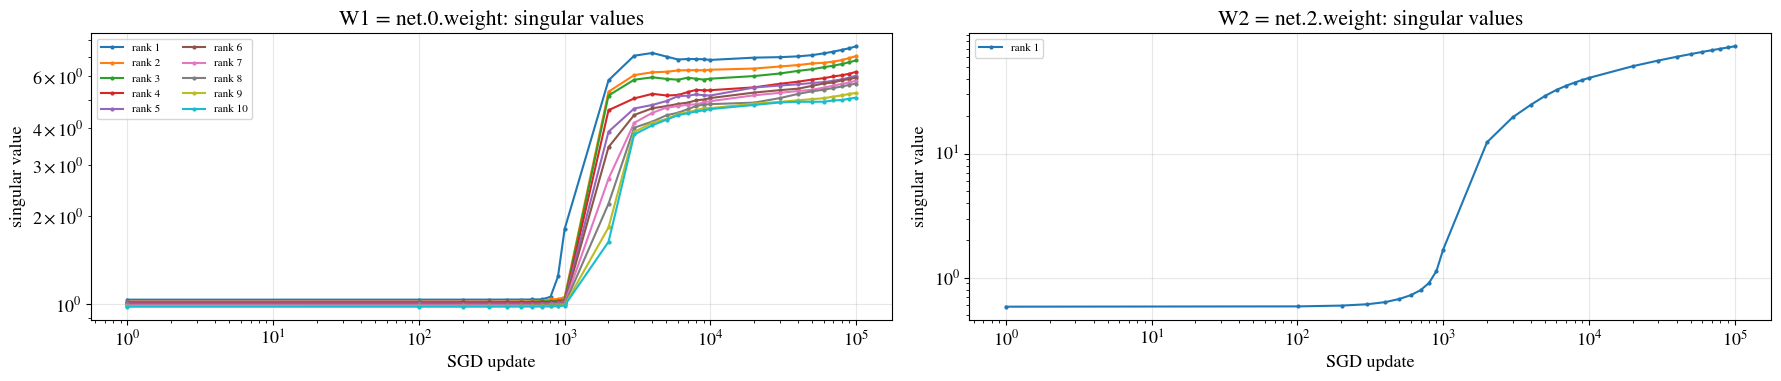

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
updates = spectra_history["updates"]

for rank in range(spectra_history["W1_singular"].shape[1]):
    axes[0].plot(updates, spectra_history["W1_singular"][:, rank], marker="o", markersize=2, label=f"rank {rank + 1}")

for rank in range(spectra_history["W2_singular"].shape[1]):
    axes[1].plot(updates, spectra_history["W2_singular"][:, rank], marker="o", markersize=2, label=f"rank {rank + 1}")

axes[0].set_title("W1 = net.0.weight: singular values")
axes[1].set_title("W2 = net.2.weight: singular values")

for ax in axes:
    ax.set_xlabel("SGD update")
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

axes[0].set_ylabel("singular value")
axes[1].set_ylabel("singular value")

plt.tight_layout()
plt.show()


## Data PCA Basis


In [7]:
with torch.no_grad():
    centered_data = train_visible - train_visible.mean(dim=0, keepdim=True)
    cov_data = centered_data.t() @ centered_data / max(1, train_visible.shape[0] - 1)
    _, _, V_dataT = torch.linalg.svd(cov_data)
    data_proj = train_visible @ V_dataT.mT
    data_proj = data_proj.detach().cpu().numpy()

print("data_proj", data_proj.shape)


data_proj (60000, 784)


## Final Permanent Chains


In [8]:
final_update = int(saved_updates[-1])
params, perm_chains, _ = load_model(filename, final_update, device=device, dtype=dtype)

perm_visible = perm_chains["visible"].detach().cpu()
perm_proj = perm_chains["visible"] @ V_dataT.mT
perm_proj = perm_proj.cpu().numpy()

print("loaded update", final_update)
print("permanent chains", tuple(perm_visible.shape))


loaded update 100000
permanent chains (1024, 784)


(<Figure size 1600x400 with 16 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

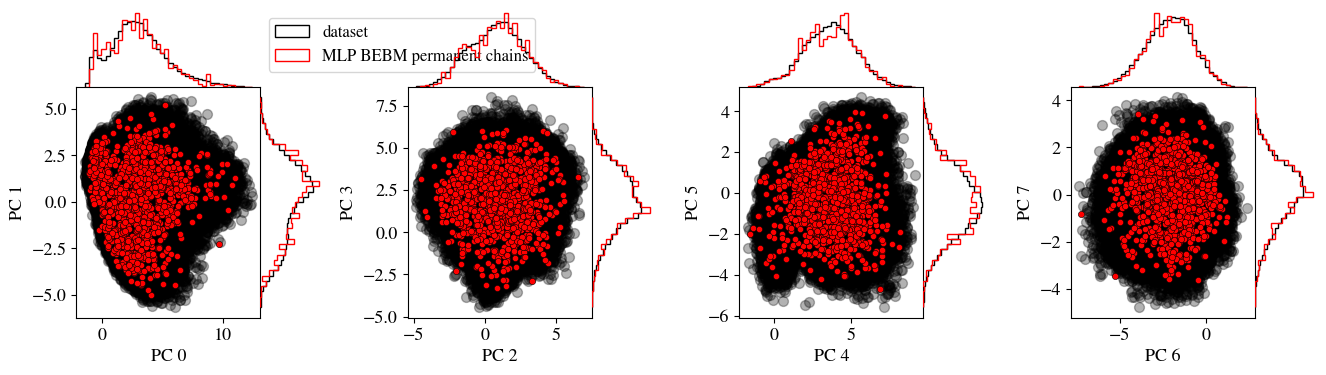

In [9]:
plot_mult_PCA(
    data_proj[:, :8],
    perm_proj[:, :8],
    labels=["dataset", "MLP BEBM permanent chains"],
)


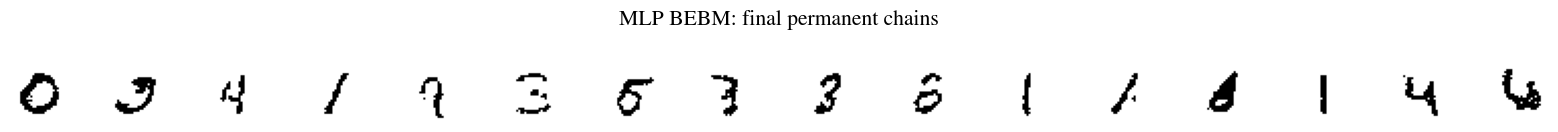

In [22]:
plot_binary_rows(
    {final_update: perm_visible},
    title="MLP BEBM: final permanent chains",
    samples_per_checkpoint=16,
)


## Generated Samples Over Training


In [18]:
TRAINING_SAMPLE_NUM_CHECKPOINTS = 5
TRAINING_SAMPLE_NUM_CHAINS = 512
TRAINING_SAMPLE_STEPS = 10000
TRAINING_DMALA_ALPHA = 0.3

sample_updates = selected_updates_linear(saved_updates, TRAINING_SAMPLE_NUM_CHECKPOINTS)
training_samples = {}
training_sample_proj = {}

torch.manual_seed(0)
initial_visible = torch.bernoulli(torch.full((TRAINING_SAMPLE_NUM_CHAINS, num_visibles), 0.5, device=device, dtype=dtype))

for update in tqdm(sample_updates, desc="Samples over training"):
    params = load_params(filename, int(update), device=device, dtype=dtype)
    chains = params.init_chains(num_samples=TRAINING_SAMPLE_NUM_CHAINS, start_v=initial_visible)
    chains = params.sample_state(
        chains=chains,
        n_steps=TRAINING_SAMPLE_STEPS,
        kernel="dmala",
        kernel_params={"alpha": TRAINING_DMALA_ALPHA},
    )

    visible = chains["visible"].detach()
    training_samples[int(update)] = visible.cpu()
    training_sample_proj[int(update)] = (visible @ V_dataT.mT).cpu().numpy()


Samples over training: 100%|██████████| 5/5 [07:21<00:00, 88.21s/it]


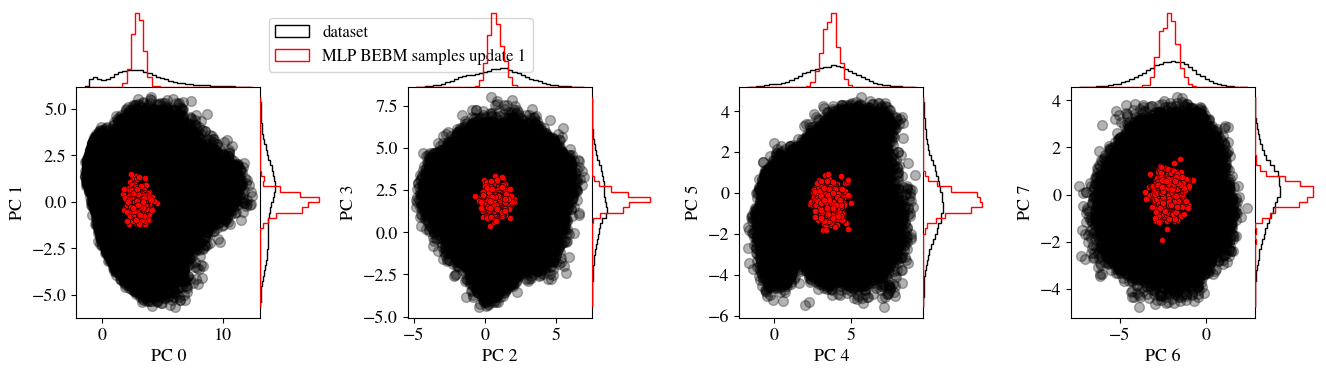

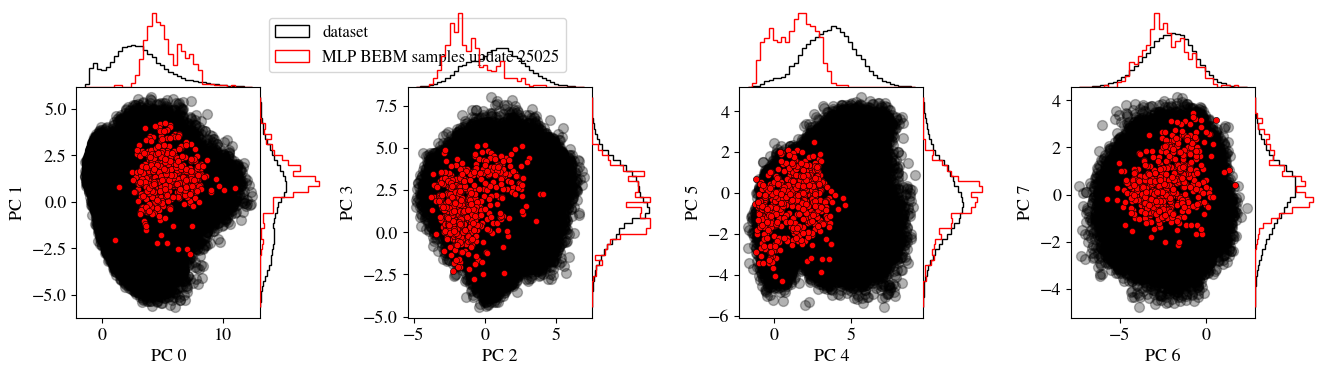

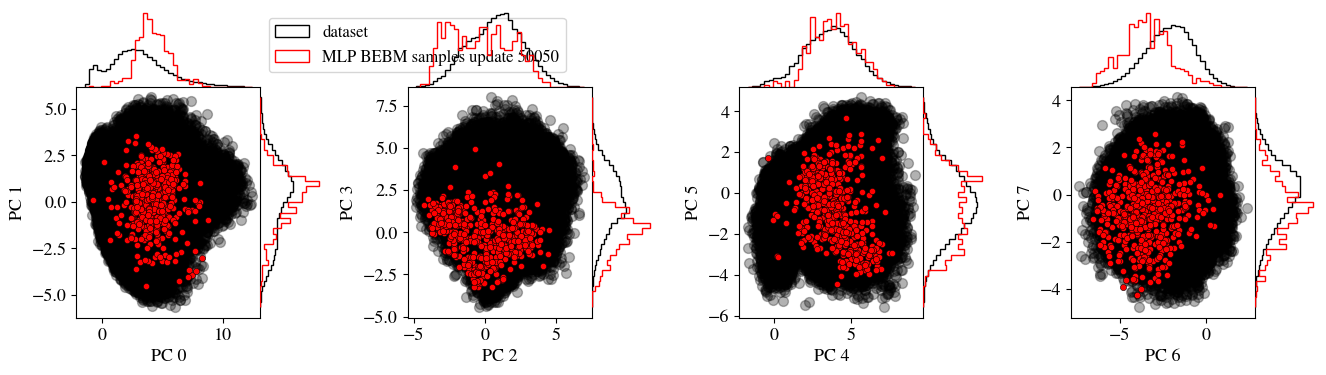

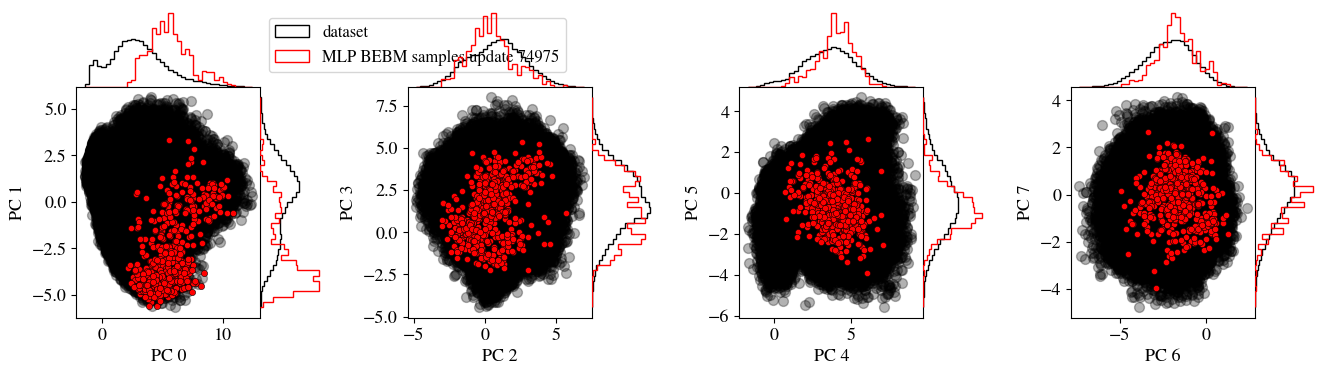

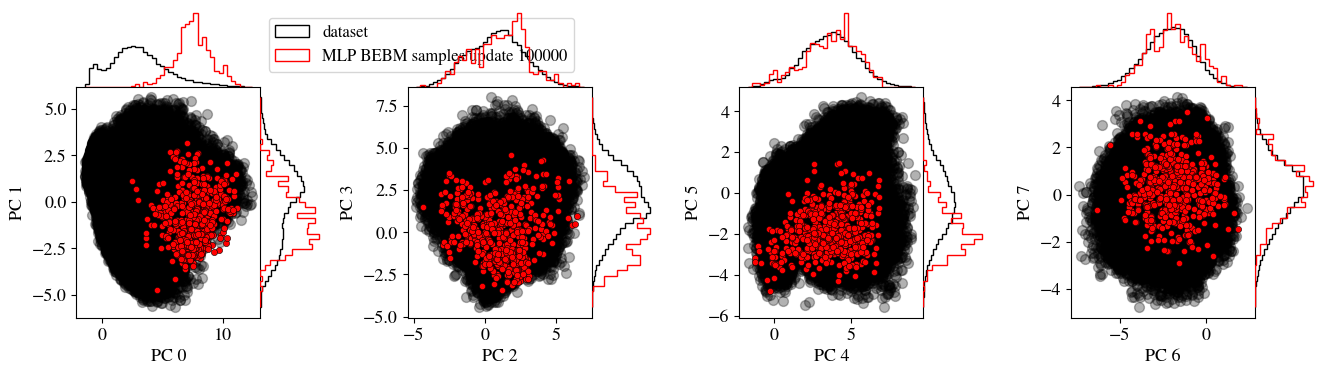

In [19]:
for update, pc_proj in training_sample_proj.items():
    plot_mult_PCA(
        data_proj[:, :8],
        pc_proj[:, :8],
        labels=["dataset", f"MLP BEBM samples update {update}"],
    )


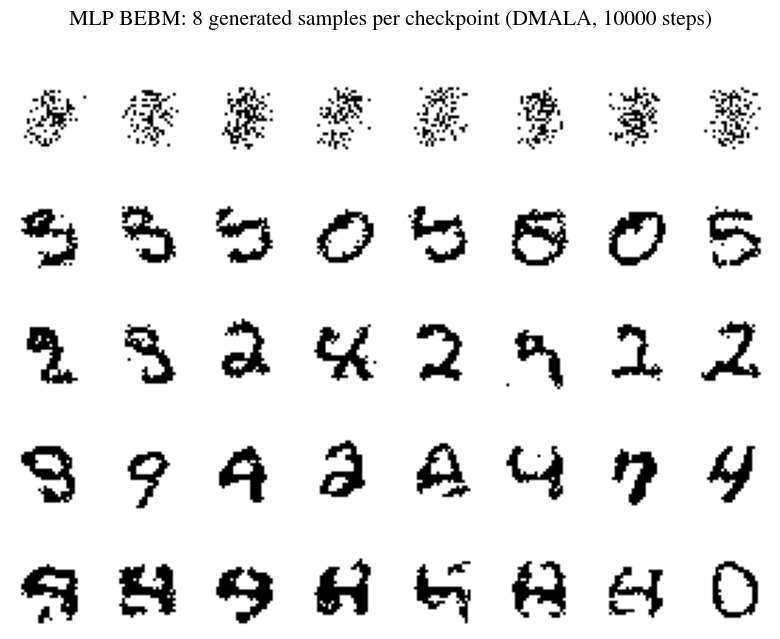

In [20]:
plot_binary_rows(
    training_samples,
    title=f"MLP BEBM: 8 generated samples per checkpoint (DMALA, {TRAINING_SAMPLE_STEPS} steps)",
    samples_per_checkpoint=8,
)


# Sampling starting from permanent chains

Sampling initialising from permanent chains instead of random over training checkpoints

In [25]:
PERM_SAMPLE_NUM_CHECKPOINTS = 5
PERM_SAMPLE_NUM_CHAINS = 512
PERM_SAMPLE_STEPS = 1000
PERM_DMALA_ALPHA = 0.3

perm_sample_updates = selected_updates_linear(
    saved_updates,
    PERM_SAMPLE_NUM_CHECKPOINTS,
)

perm_started_samples_by_update = {}
perm_started_proj_by_update = {}

for update in tqdm(perm_sample_updates, desc="Permanent-start samples"):
    params, perm_chains, _ = load_model(
        filename,
        int(update),
        device=device,
        dtype=dtype,
    )

    initial_visible = perm_chains["visible"][:PERM_SAMPLE_NUM_CHAINS].clone()

    chains = params.init_chains(
        num_samples=PERM_SAMPLE_NUM_CHAINS,
        start_v=initial_visible,
    )

    chains = params.sample_state(
        chains=chains,
        n_steps=PERM_SAMPLE_STEPS,
        kernel="dmala",
        kernel_params={"alpha": PERM_DMALA_ALPHA},
    )

    visible = chains["visible"].detach()

    perm_started_samples_by_update[int(update)] = visible.cpu()
    perm_started_proj_by_update[int(update)] = (
        visible @ V_dataT.mT
    ).cpu().numpy()

    print(f"update {int(update)}: sampled {tuple(visible.shape)}")


Permanent-start samples:  20%|██        | 1/5 [00:10<00:40, 10.02s/it]

update 1: sampled (512, 784)


Permanent-start samples:  40%|████      | 2/5 [00:20<00:30, 10.06s/it]

update 25025: sampled (512, 784)


Permanent-start samples:  60%|██████    | 3/5 [00:29<00:19,  9.96s/it]

update 50050: sampled (512, 784)


Permanent-start samples:  80%|████████  | 4/5 [00:39<00:09,  9.94s/it]

update 74975: sampled (512, 784)


Permanent-start samples: 100%|██████████| 5/5 [00:48<00:00,  9.80s/it]

update 100000: sampled (512, 784)


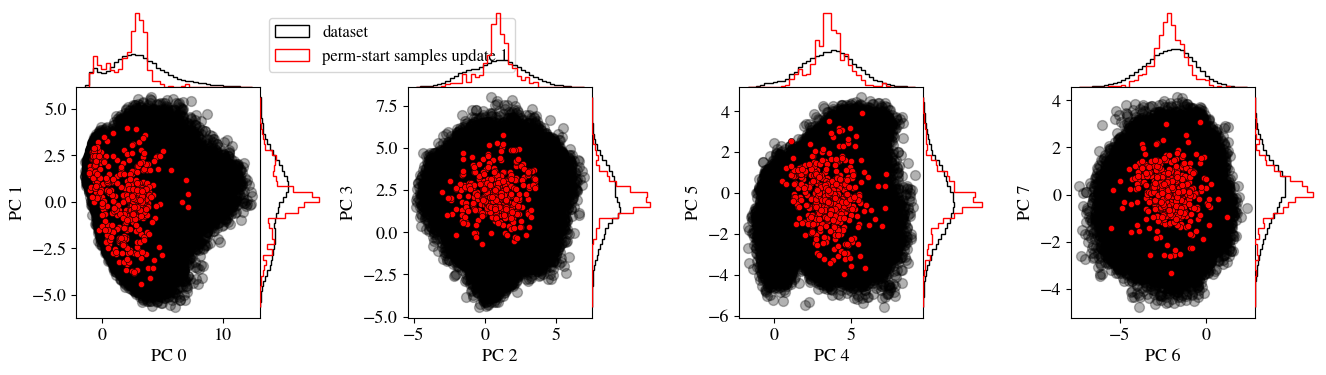

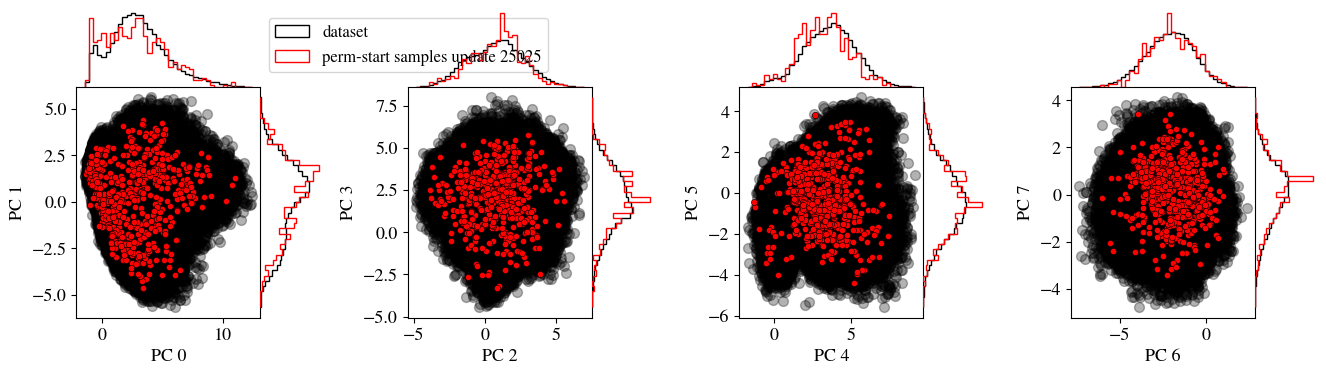

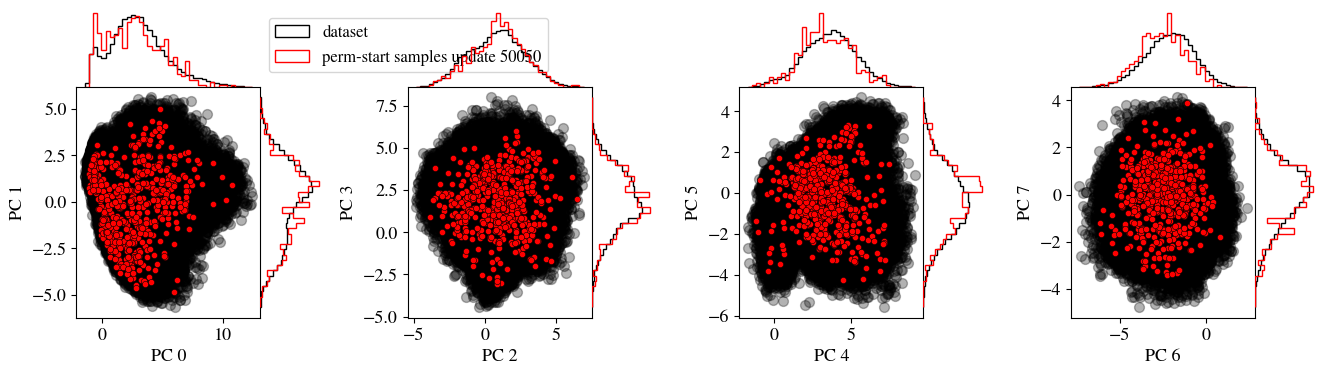

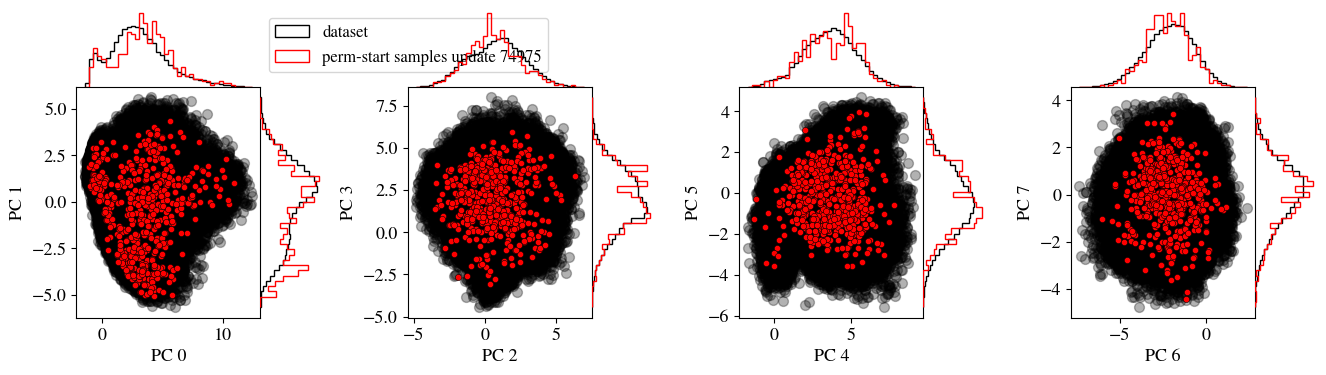

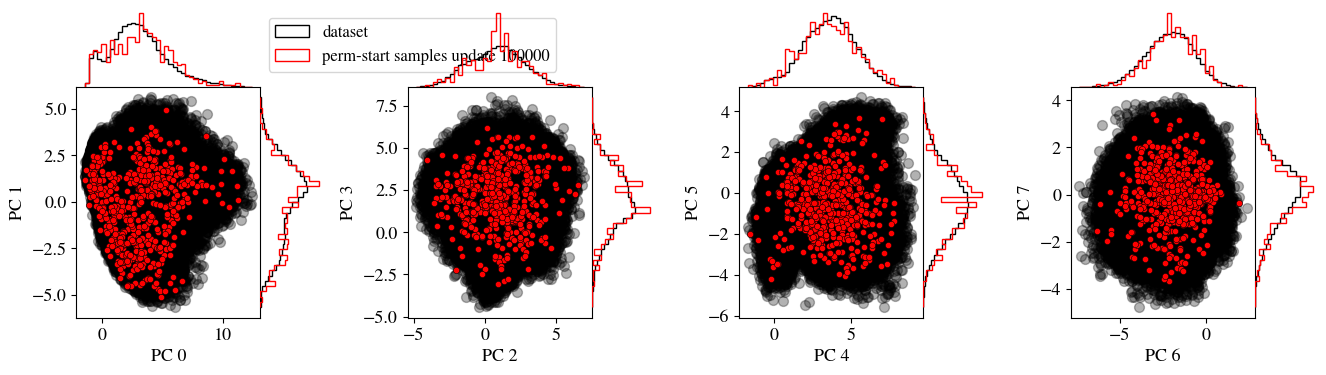

In [26]:
for update, pc_proj in perm_started_proj_by_update.items():
    plot_mult_PCA(
        data_proj[:, :8],
        pc_proj[:, :8],
        labels=[
            "dataset",
            f"perm-start samples update {update}",
        ],
    )


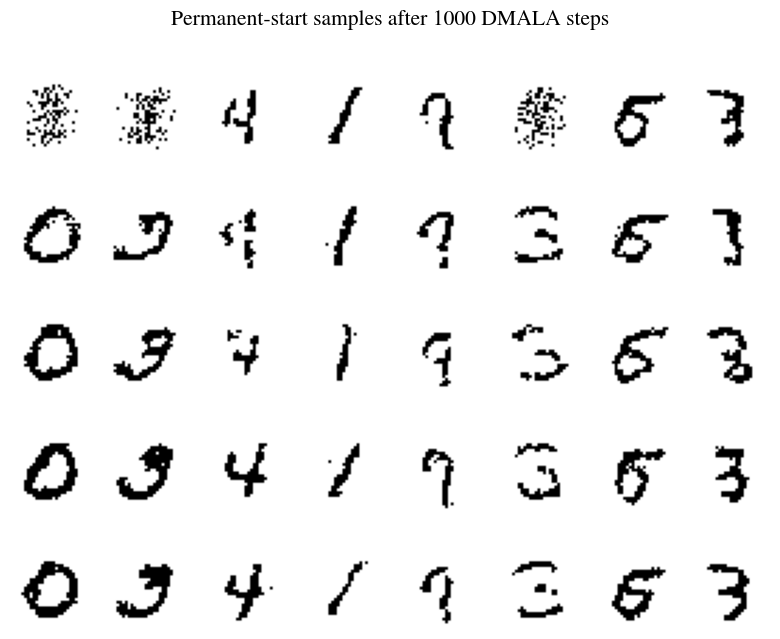

In [27]:
SAMPLES_PER_CHECKPOINT = 8

num_rows = len(perm_started_samples_by_update)

fig, axes = plt.subplots(
    num_rows,
    SAMPLES_PER_CHECKPOINT,
    figsize=(SAMPLES_PER_CHECKPOINT, 1.35 * num_rows),
    squeeze=False,
)

for row, (update, visible) in enumerate(perm_started_samples_by_update.items()):
    for col in range(SAMPLES_PER_CHECKPOINT):
        ax = axes[row, col]
        ax.imshow(
            visible[col].view(*IMAGE_SHAPE),
            cmap="gray_r",
            vmin=0,
            vmax=1,
        )
        ax.axis("off")

    axes[row, 0].set_ylabel(
        f"update {update}",
        rotation=0,
        labelpad=40,
        va="center",
        fontsize=10,
    )

fig.suptitle(
    f"Permanent-start samples after {PERM_SAMPLE_STEPS} DMALA steps"
)

plt.tight_layout()
plt.show()


## Mixing-Time Diagnostic for the Final MLP EBM

This uses the model's own DMALA transition kernel and estimates the spin autocorrelation time.


In [14]:
def spin_autocorr_fft(spins, max_lag, component_batch=4096, fft_device=None):
    if fft_device is None:
        fft_device = device

    num_times, num_chains, num_visibles = spins.shape
    max_lag = min(max_lag, num_times - 1)

    mean_spin = spins.to(torch.float32).mean(dim=(0, 1)).cpu()
    flat = spins.reshape(num_times, num_chains * num_visibles)
    n_fft = 1 << (2 * num_times - 1).bit_length()

    counts = torch.arange(num_times, num_times - max_lag - 1, -1, device=fft_device, dtype=torch.float32)
    numerator = torch.zeros(max_lag + 1, dtype=torch.float64)
    denominator = torch.tensor(0.0, dtype=torch.float64)

    for col_start in tqdm(range(0, flat.shape[1], component_batch), leave=False):
        col_stop = min(col_start + component_batch, flat.shape[1])
        block = flat[:, col_start:col_stop].to(device=fft_device, dtype=torch.float32)

        pixel_indices = torch.arange(col_start, col_stop, device="cpu") % num_visibles
        block = block - mean_spin[pixel_indices].to(fft_device).view(1, -1)

        block_fft = torch.fft.rfft(block, n=n_fft, dim=0)
        autocov = torch.fft.irfft(block_fft.abs().square(), n=n_fft, dim=0)[: max_lag + 1]
        autocov = autocov / counts[:, None]

        numerator += autocov.sum(dim=1).detach().cpu().double()
        denominator += autocov[0].sum().detach().cpu().double()

    return (numerator / denominator.clamp_min(1e-12)).numpy()


def collect_dmala_spin_trajectory(params, num_chains, num_steps, alpha=0.5):
    visible = torch.bernoulli(torch.full((num_chains, num_visibles), 0.5, device=device, dtype=dtype))
    chains = params.init_chains(num_samples=num_chains, start_v=visible)

    spins = torch.empty((num_steps + 1, num_chains, num_visibles), dtype=torch.int8, device="cpu")

    for step in tqdm(range(num_steps + 1), desc="MLP DMALA trajectory"):
        spins[step].copy_((2.0 * chains["visible"].detach().cpu() - 1.0).to(torch.int8))
        if step < num_steps:
            chains = params.sample_state(
                chains=chains,
                n_steps=1,
                kernel="dmala",
                kernel_params={"alpha": alpha},
            )

    return spins


In [15]:
MIX_NUM_CHAINS = 256
MIX_NUM_STEPS = 10_000
MIX_MAX_LAG = 5_000
MIX_DMALA_ALPHA = 0.5

final_params = load_params(filename, int(saved_updates[-1]), device=device, dtype=dtype)
spins = collect_dmala_spin_trajectory(
    params=final_params,
    num_chains=MIX_NUM_CHAINS,
    num_steps=MIX_NUM_STEPS,
    alpha=MIX_DMALA_ALPHA,
)

rho = spin_autocorr_fft(spins, max_lag=MIX_MAX_LAG, fft_device=device)


MLP DMALA trajectory: 100%|██████████| 10001/10001 [01:00<00:00, 165.55it/s]


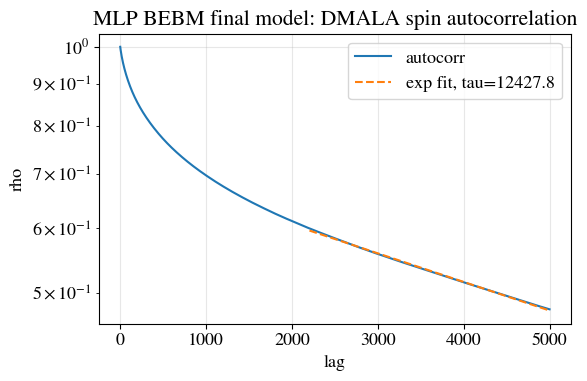

exponential tau = 12427.83 DMALA steps


In [21]:
FIT_MIN_RHO = 0.05
FIT_MAX_RHO = 0.6

lags = np.arange(len(rho))
rho_positive = np.clip(rho, 1e-12, None)
fit_mask = (lags > 0) & np.isfinite(rho) & (rho > FIT_MIN_RHO) & (rho < FIT_MAX_RHO)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(lags, rho_positive, label="autocorr")

if fit_mask.sum() >= 2:
    slope, intercept = np.polyfit(lags[fit_mask], np.log(rho[fit_mask]), deg=1)
    tau_exp = -1.0 / slope if slope < 0 else np.inf
    fit_lags = lags[fit_mask]
    fit_curve = np.exp(intercept + slope * fit_lags)
    ax.plot(fit_lags, fit_curve, "--", label=f"exp fit, tau={tau_exp:.1f}")
else:
    tau_exp = np.nan

ax.set_title("MLP BEBM final model: DMALA spin autocorrelation")
ax.set_xlabel("lag")
ax.set_ylabel("rho")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"exponential tau = {tau_exp:.2f} DMALA steps")
